import necessary packages and define some custom functions

In [ ]:
from mplhockey import PWHLRink
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def get_SHAA(ps,pg,ts,tg):
    shaa = pg/ps-tg/ts
    return shaa

def get_SP(ps,ts):
    sp = np.divide(ps,ps.sum()) - np.divide(ts,ts.sum())
    return sp

#this is not really xG but the PWHL doesn't have nearly as much data available as the NHL
#it's what we're got so far
def get_xG(ps,ts,tg):
    xG = ps*tg/ts
    return xG

import data and transform the shot locations onto the axes that mplhockey expects. Also, set up some grids for plotting

In [ ]:
ds = pd.read_csv('./PBP_PWHL_20252026_shots.csv')
players = pd.read_csv('./PWHL_Playerdata_2.csv')
rink = PWHLRink(units='m')

##convert PWHL shot location data to the axes that mplhockey expects
ds['xLocation']=ds['xLocation']/10-30
ds['yLocation']=ds['yLocation']/10-15

#plotting grids
x_grid = np.linspace(0,30,31)
y_grid = np.linspace(-13,13,27)

X,Y = np.meshgrid(x_grid,y_grid)
posns = np.vstack([X.ravel(),Y.ravel()])

for some reason the y-axis for PWHL data is swapped from the actual shot locations as seen on the ice. This was identified by looking at the shot map of Sophie Jaques (RHD, tends to shoot from the point) and confirmed via re-watching games. This next loop fixes this issue and positions all shot locations on the same side of the ice (to do: account for shots on an empty net & exceptions that might actually be on the other side of centre)

In [ ]:
ds2=ds
for loc in ds['xLocation'].index:
    if ds['xLocation'][loc]<0:
        ds2['xLocation'][loc] = -1*ds['xLocation'][loc]
    else:
        ds2['yLocation'][loc] = -1*ds['yLocation'][loc]


Simplify processing by only keeping the columns we care about

In [ ]:
ds2 = ds2[['Shooter','xLocation','yLocation','shotQuality']].dropna()


shotquality_dict = {
    'Quality goal':1,
    'Non quality goal':1,
    'Quality on net':2,
    'Non quality on net':2}

#give shot quality irrespective of goal status a numerical value
ds2['shotQuality_num'] = [shotquality_dict[i] for i in ds2['shotQuality']]

Defenders and forwards have distinctly different shot patterns and shot intentionality. To make sure we're comparing like with like, we separate out by position played. Edit this cell to change whether you're looking at Forwards or Defenders!

In [36]:
#edit this to try different bin sizes for the 2D histogram
bins = 6

#edit this to choose whether to plot forwards or defenders
POSN = 'F' #or 'D'

#minimum number of shots taken in the 2025-2026 season to qualify for their own plot
#adjust this number between F and D since F shoot way more
min_shots = 50

#list of types of plots to make for each player meeting the above criteria. 
# select from 'SHAA', 'SP' (shooting preference), 'xG' (expected goals - EXTREMELY rudimentary)
plot_types = ['xG']

posn_dict={
    'F':'forward',
    'D':'defender'
}

list_of_posn_players = players.loc[players['pos']==POSN]['PlayerID'].values



Generate the plots for the set of criteria selected above

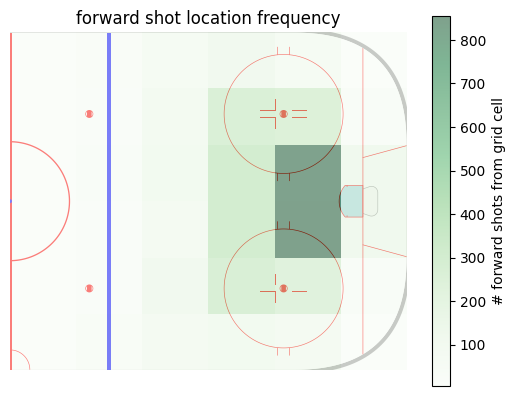

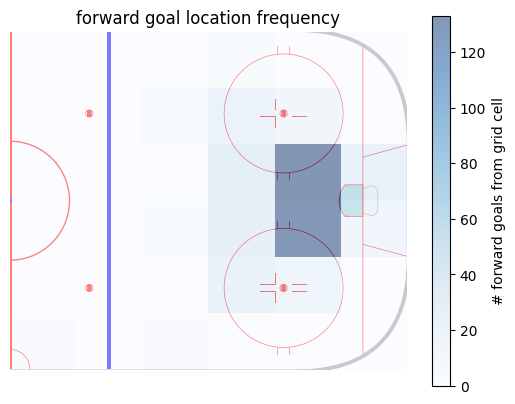

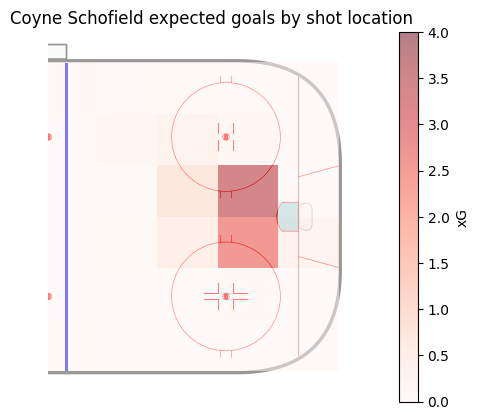

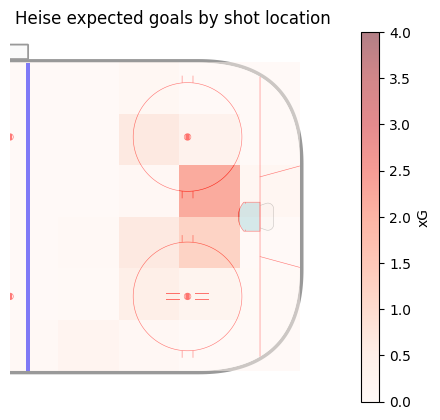

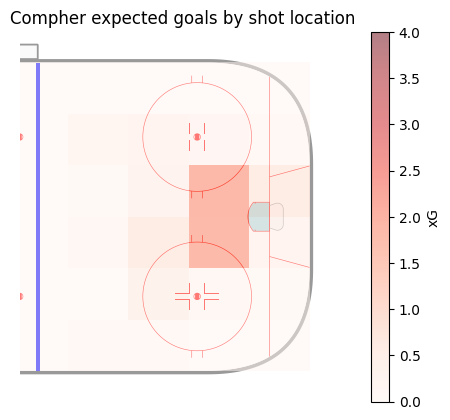

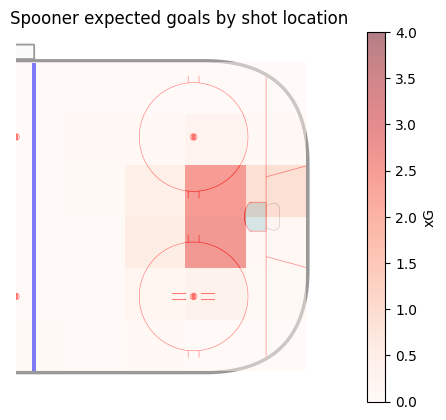

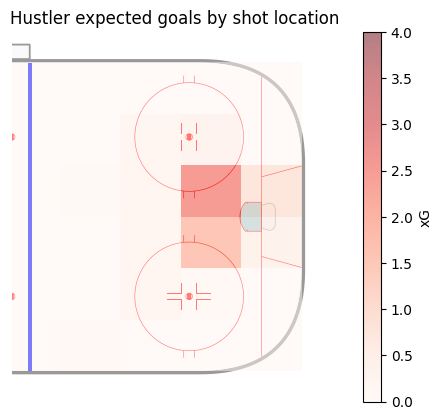

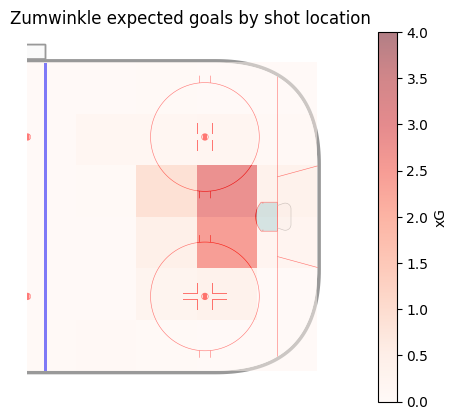

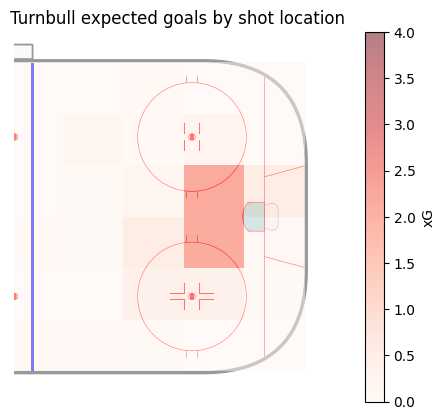

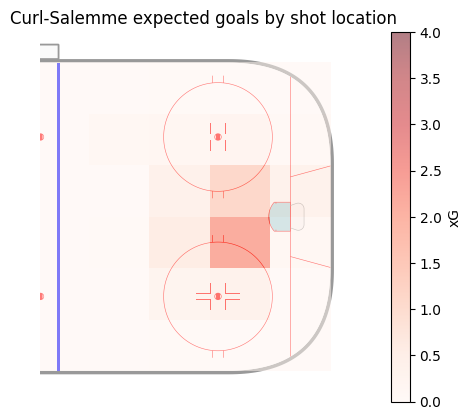

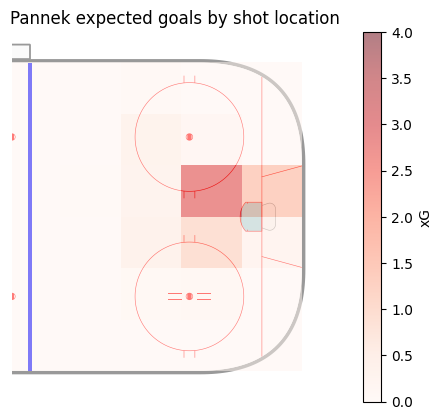

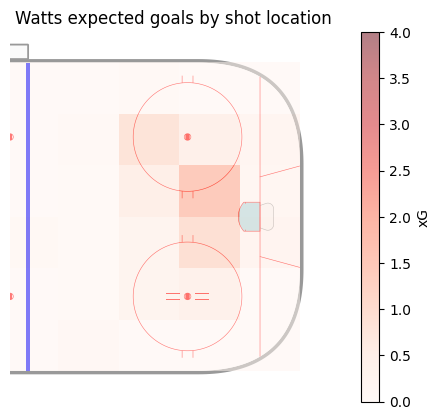

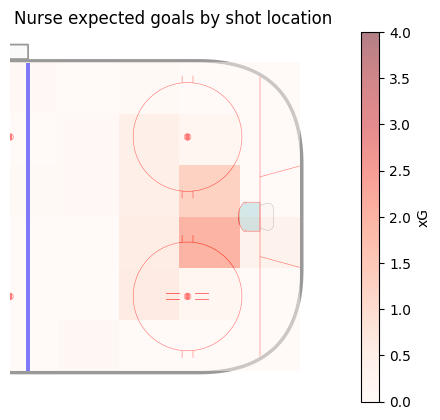

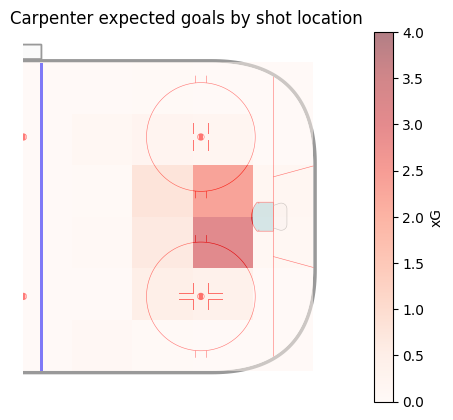

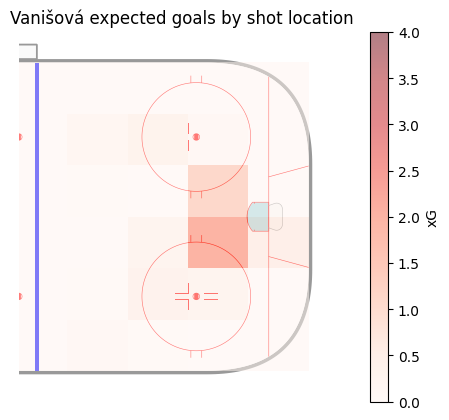

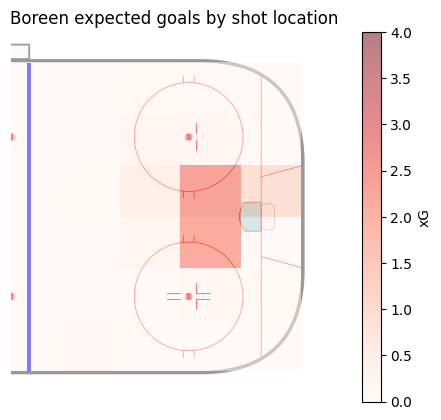

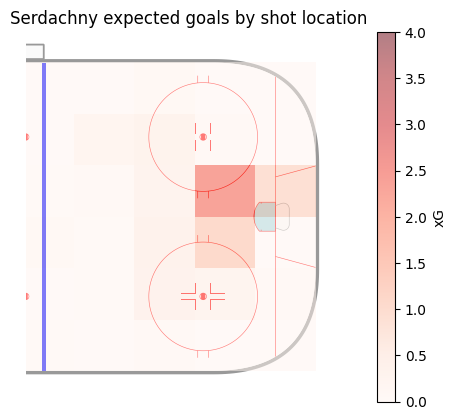

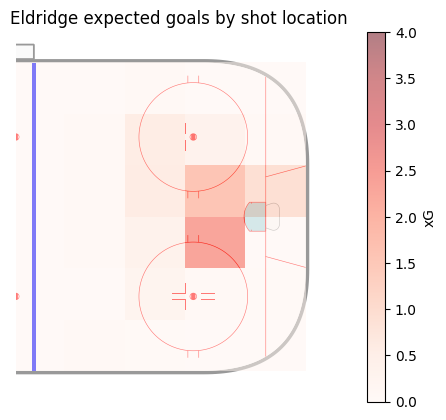

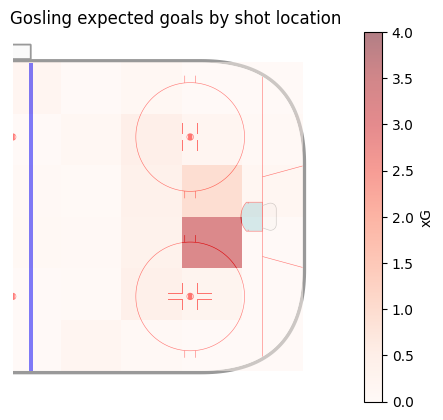

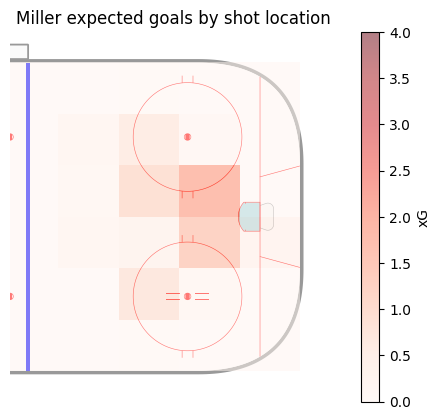

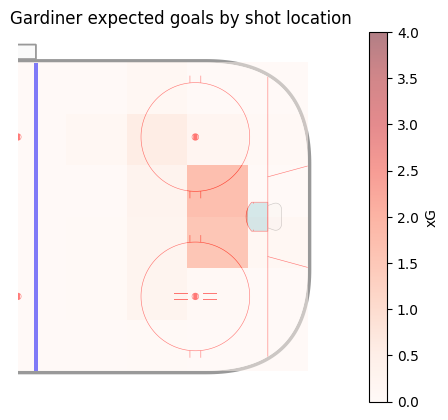

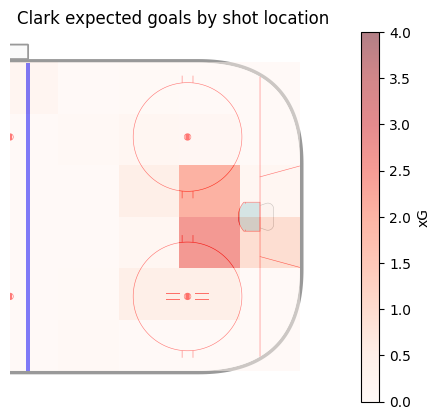

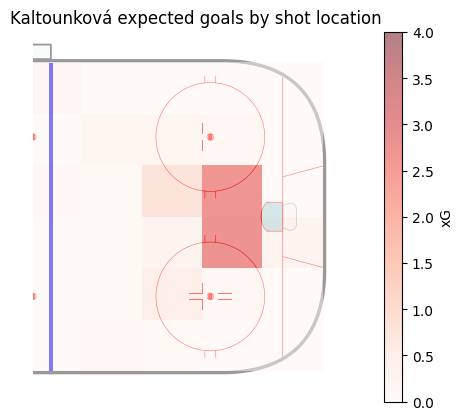

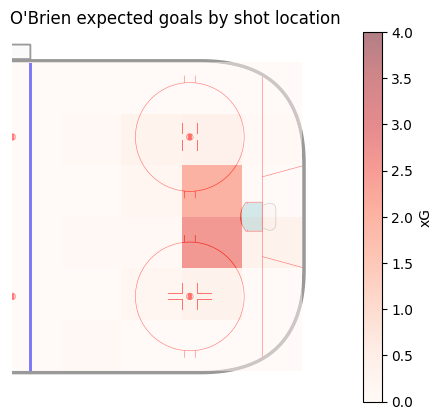

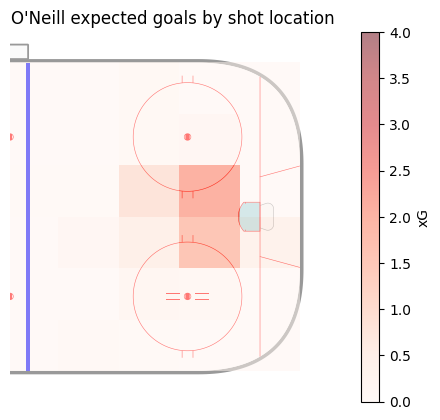

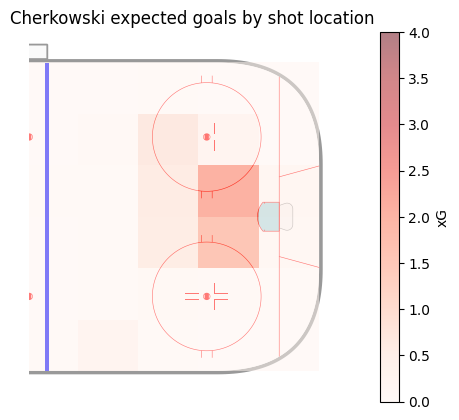

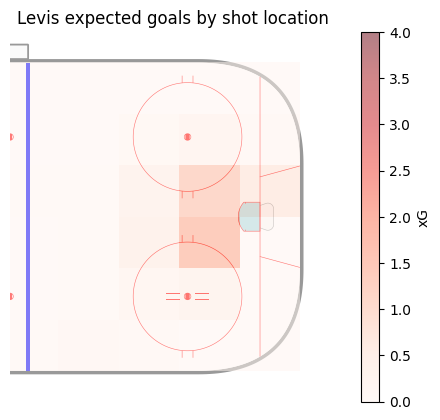

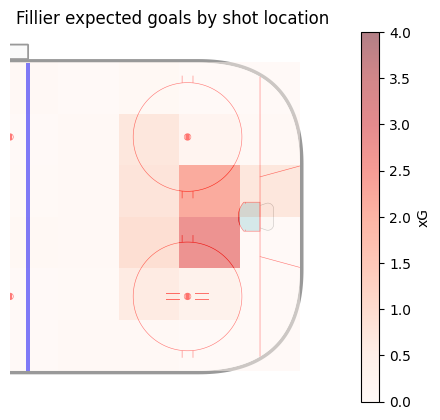

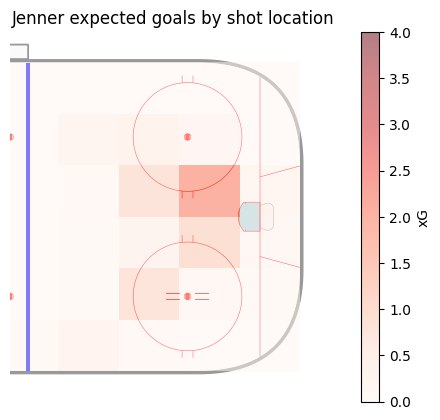

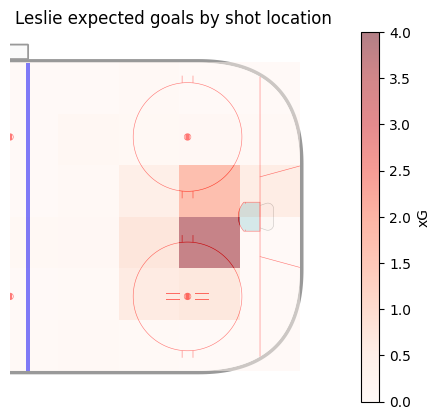

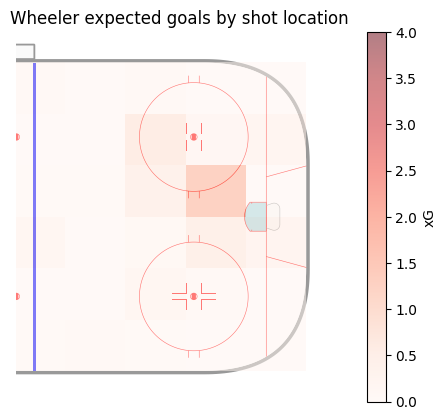

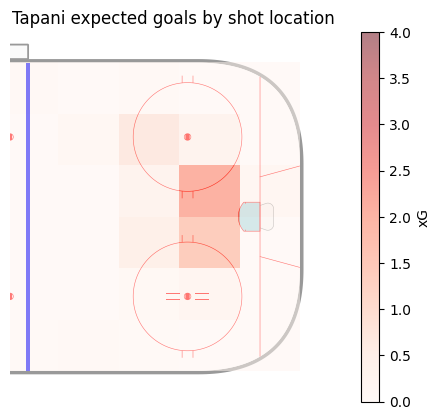

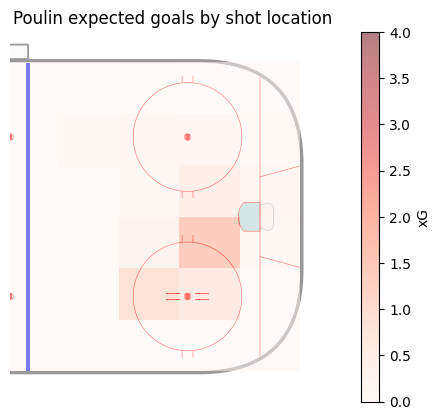

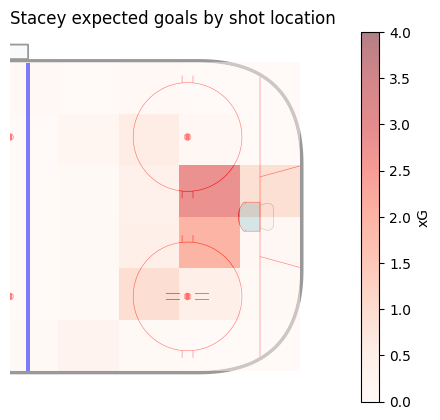

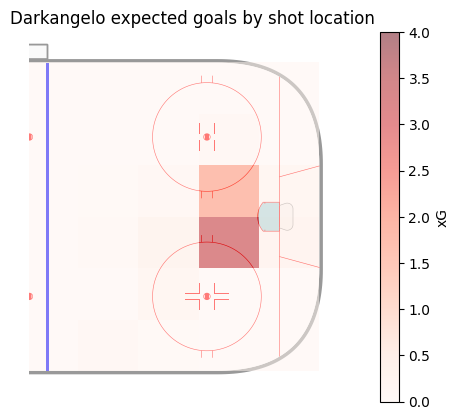

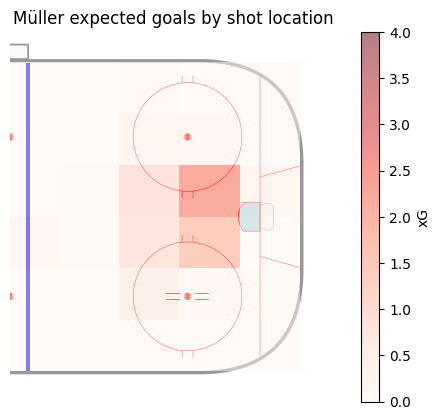

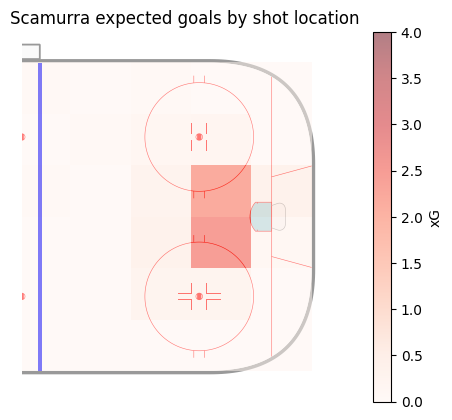

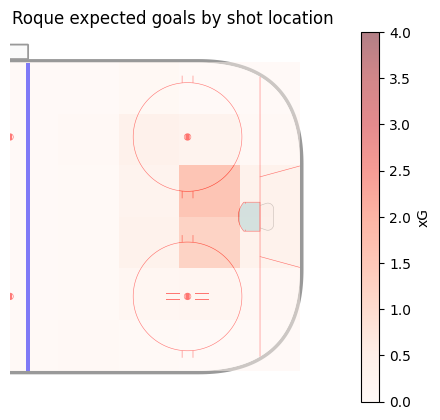

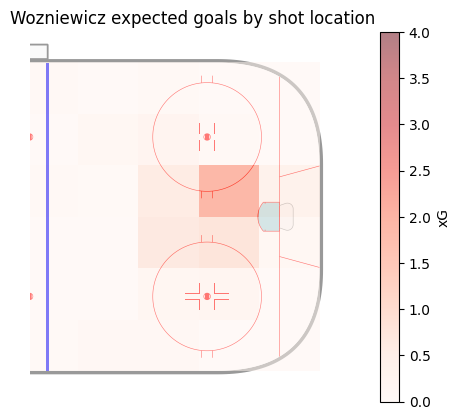

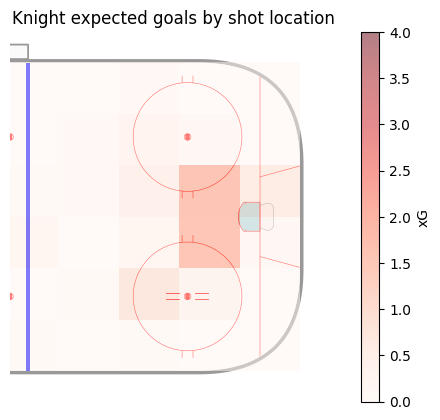

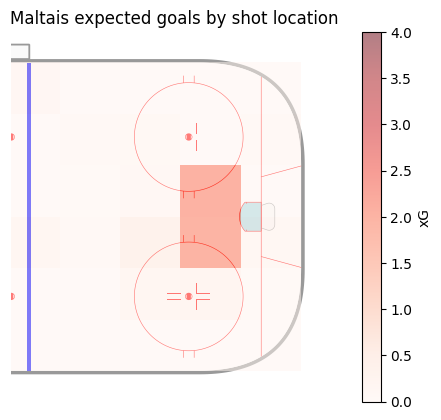

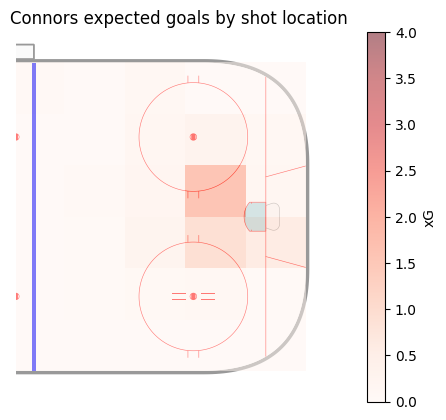

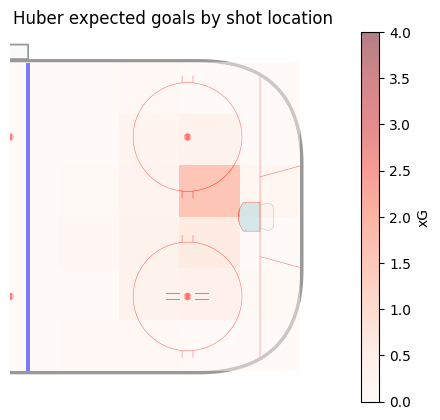

In [41]:
ds3 = ds2.loc[ds2['Shooter'].isin(list_of_posn_players)]
ds4 = ds3.loc[ds3['shotQuality'].isin(['Quality goal','Non quality goal'])]  

fig, ax = plt.subplots()
rink.draw(ax=ax,display_range='ozone')
ax.set_axis_off()
totalshots, xedges, yedges, image = plt.hist2d(ds3['xLocation'],ds3['yLocation'],bins=bins,alpha=0.5,range=[[0, 30.5], [-13, 13]],cmap='Greens')
plt.colorbar(label='# '+posn_dict[POSN]+' shots from grid cell')
plt.title(posn_dict[POSN]+' shot location frequency')

fig, ax = plt.subplots()
rink.draw(ax=ax,display_range='ozone')
ax.set_axis_off()
totalgoals, xedges2, yedges2, image2 = plt.hist2d(ds4['xLocation'],ds4['yLocation'],bins=bins,alpha=0.5,range=[[0, 30.5], [-13, 13]],cmap='Blues')
plt.colorbar(label='# '+posn_dict[POSN]+' goals from grid cell')
plt.title(posn_dict[POSN]+' goal location frequency')

for playerid in ds3['Shooter'].unique():
    if ds3.where(ds3['Shooter']==playerid).dropna().count()['Shooter']>min_shots and players.where(players['PlayerID']==playerid).count()['PlayerID']>0: 
        playershots, xedges1, yedges1, = np.histogram2d(ds3.where(ds['Shooter']==playerid).dropna()['xLocation'],ds3.where(ds['Shooter']==playerid).dropna()['yLocation'],bins=bins,range=[[0, 30.5], [-13, 13]])
        playergoals, xedges3, yedges3, = np.histogram2d(ds4.where(ds['Shooter']==playerid).dropna()['xLocation'],ds4.where(ds['Shooter']==playerid).dropna()['yLocation'],bins=bins,range=[[0, 30.5], [-13, 13]])

        if 'xG' in plot_types:
            fig, ax = plt.subplots()
            rink.draw(ax=ax,display_range='ozone')
            ax.set_axis_off()
            im = ax.pcolormesh(xedges, yedges, get_xG(playershots,totalshots,totalgoals).T, alpha=0.5,cmap='Reds',vmin=0,vmax=4)
            fig.colorbar(im, ax=ax,label='xG')
            plt.title(players.where(players['PlayerID']==playerid).dropna()['Name'].values[0].split(" ",1)[-1]+' expected goals by shot location')
            plt.show()

        if 'SHAA' in plot_types:
            fig, ax = plt.subplots()
            rink.draw(ax=ax,display_range='ozone')
            ax.set_axis_off()
            im = ax.pcolormesh(xedges, yedges, get_SHAA(playershots,playergoals,totalshots,totalgoals).T,alpha=0.5, cmap='bwr',vmin=-0.3,vmax=0.3)
            fig.colorbar(im, ax=ax,label='SH% - avg SH%')
            plt.title(players.where(players['PlayerID']==playerid).dropna()['Name'].values[0].split(" ",1)[-1]+' SH%AA for a '+posn_dict[POSN])
            plt.show()

        if 'SP' in plot_types:
            fig, ax = plt.subplots()
            rink.draw(ax=ax,display_range='ozone')
            ax.set_axis_off()
            im = ax.pcolormesh(xedges, yedges, get_SP(playershots,totalshots).T,alpha=0.5, cmap='bwr',vmin=-0.15,vmax=0.15)
            fig.colorbar(im, ax=ax,label='player positional shooting preference, %pts')
            plt.title(players.where(players['PlayerID']==playerid).dropna()['Name'].values[0].split(" ",1)[-1]+' shot location vs avg '+posn_dict[POSN])
            plt.show()